In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
#reading csv file

train = pd.read_csv('/kaggle/input/titanic/train.csv')
test = pd.read_csv('/kaggle/input/titanic/test.csv')
#submission = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

In [3]:
#submission.head()

In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
# check shape of dataframe

train.shape,test.shape

((891, 12), (418, 11))

In [7]:
# info about dataframe

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [9]:
# checking null values

train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
# fill null values of Age feature by mean

train['Age'].fillna(train['Age'].mean(),inplace = True)
test['Age'].fillna(test['Age'].mean(),inplace = True)

In [11]:
# check columns

train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [12]:
# drop unnecessary columns

train.drop(['PassengerId','Name','Ticket','Fare','Cabin','Embarked'],axis = 1, inplace = True)
test.drop(['Name','Ticket','Fare','Cabin','Embarked'],axis = 1, inplace = True)

In [13]:
# have a look at top rows

train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch
0,0,3,male,22.0,1,0
1,1,1,female,38.0,1,0
2,1,3,female,26.0,0,0
3,1,1,female,35.0,1,0
4,0,3,male,35.0,0,0


In [14]:
# check for missing values, now.

train.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
dtype: int64

In [15]:
# replace male/female by 0/1

train['Sex'] = train['Sex'].replace('male',0)
train['Sex'] = train['Sex'].replace('female',1)

In [16]:
# replace male/female by 0/1

test['Sex'] = test['Sex'].replace('male',0)
test['Sex'] = test['Sex'].replace('female',1)

In [17]:
# value count for survived

train['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

## EDA

In [18]:
# import seaborn library

import seaborn as sns

<AxesSubplot:xlabel='Survived', ylabel='count'>

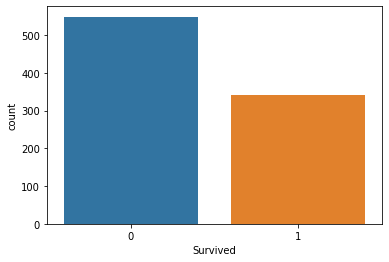

In [19]:
# countplot for survived

# survived = 1
# not survived = 0
sns.countplot(data=train, x='Survived')

<AxesSubplot:xlabel='Survived', ylabel='count'>

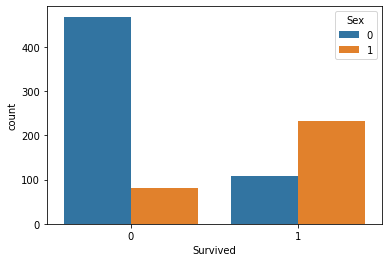

In [20]:
# survived based on Sex

sns.countplot(data=train, x='Survived', hue = 'Sex')

# 0 - Male 1 - Female
# 0 - Not survived 1- survived

* Most of the male Passengers did not survived as compared to female.

<AxesSubplot:xlabel='Pclass', ylabel='count'>

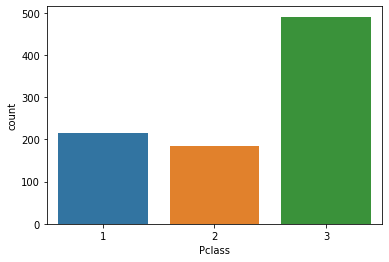

In [21]:
# count plot for Pclass

sns.countplot(data = train, x='Pclass')

* Highest count of passengers belongs to Pclass 3.

<AxesSubplot:xlabel='Pclass', ylabel='count'>

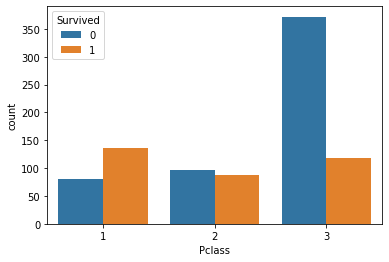

In [22]:
sns.countplot(x='Pclass', hue='Survived', data=train)

* As you can see, Pclass 3 with blue bar is higher, which means most of the passengers did not survived from Pclass 3. 
* It makes sense, too, I guess.

<AxesSubplot:xlabel='Survived', ylabel='Age'>

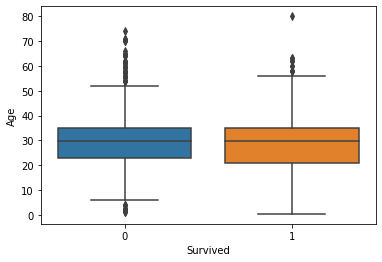

In [23]:

# survived by age

sns.boxplot(data=train, y='Age', x='Survived')

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Age', ylabel='Density'>

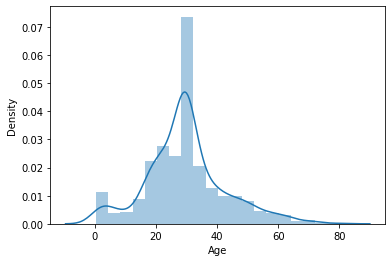

In [24]:
# Age distribution

sns.distplot(train['Age'],bins = 20)

* As we can see, more number of passengers are from age 20 - 40.

<AxesSubplot:xlabel='SibSp', ylabel='count'>

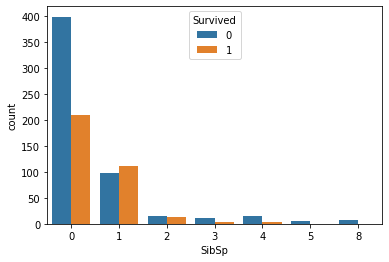

In [25]:
sns.countplot(x='SibSp',data=train,hue='Survived')

* Alone Passengers(SibSp = 0) on a ship did not survived the most (approx. 400).

In [26]:
Xtrain = train.drop('Survived',axis =1)
ytrain = train['Survived']

In [27]:
ytrain

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [28]:
Xtest = test.drop('PassengerId', axis=1).copy()

In [29]:
Xtrain.shape, ytrain.shape, Xtest.shape

((891, 5), (891,), (418, 5))

In [30]:
from sklearn.neighbors import KNeighborsClassifier

In [31]:
# check which k value gives highest score

scores = []
for k in range(1,40):
    knn = KNeighborsClassifier(k).fit(Xtrain, ytrain)
    scores.append(knn.score(Xtrain, ytrain))

print(scores, end = "  ")

[0.8855218855218855, 0.8686868686868687, 0.8709315375982043, 0.8529741863075196, 0.856341189674523, 0.8439955106621774, 0.8451178451178452, 0.8305274971941639, 0.8204264870931538, 0.813692480359147, 0.819304152637486, 0.8092031425364759, 0.819304152637486, 0.8080808080808081, 0.8159371492704826, 0.7957351290684624, 0.8024691358024691, 0.7789001122334456, 0.7968574635241302, 0.7710437710437711, 0.7800224466891134, 0.7744107744107744, 0.7687991021324355, 0.7586980920314254, 0.7710437710437711, 0.7609427609427609, 0.7710437710437711, 0.7564534231200898, 0.7620650953984287, 0.7530864197530864, 0.7665544332210998, 0.7542087542087542, 0.7631874298540965, 0.7530864197530864, 0.7564534231200898, 0.7519640852974186, 0.7519640852974186, 0.7373737373737373, 0.7396184062850729]  

In [32]:
# we will take k = 3

model= KNeighborsClassifier(n_neighbors=3)
model.fit(Xtrain,ytrain)

KNeighborsClassifier(n_neighbors=3)

In [33]:
ypred = model.predict(Xtest)

In [34]:
model.score(Xtrain,ytrain)

0.8709315375982043

In [35]:
# create dataframe
submission = pd.DataFrame({'PassengerId':test['PassengerId'],'Survived':ypred})

# convert daatframe to csvfile
submission.to_csv('submission.csv',index=False)

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0


In [36]:
from sklearn.tree import DecisionTreeClassifier

In [37]:
dt = DecisionTreeClassifier()
dt.fit(Xtrain,ytrain)

DecisionTreeClassifier()

In [38]:
dt.score(Xtrain,ytrain)

0.920314253647587

In [39]:
ypred = dt.predict(Xtest)

In [40]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

In [41]:
rf = RandomForestClassifier()
rf.fit(Xtrain,ytrain)

RandomForestClassifier()

In [42]:
rf.score(Xtrain,ytrain)

0.920314253647587

In [43]:
abc = AdaBoostClassifier()
abc.fit(Xtrain,ytrain)

AdaBoostClassifier()

In [44]:
abc.score(Xtrain,ytrain)

0.8316498316498316

In [45]:
gbc = GradientBoostingClassifier()
gbc.fit(Xtrain,ytrain)

GradientBoostingClassifier()

In [46]:
gbc.score(Xtrain, ytrain)

0.8664421997755332